# EDA & Tiền xử lý — California Housing (`1553768847-housing.csv`)

Bài toán **hồi quy**: dự đoán `median_house_value`. Theo cùng luồng **clean-first** với notebook Melbourne.
Mỗi bước gồm **Lý do** và **Phân tích** (số liệu lấy từ output thật khi chạy).

## 0. Thiết lập môi trường

Mount Google Drive và đặt thư mục làm việc để đọc `1553768847-housing.csv`.

In [19]:
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/AIO-Conquer02')
os.getcwd()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/AIO-Conquer02'

## 1. Nạp & kiểm tra tổng quan

**Lý do:** `info()` để nắm kích thước, kiểu dữ liệu và mức độ đầy đủ trước khi phân tích.

In [37]:
import pandas as pd
df = pd.read_csv('1553768847-housing.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


> 📊 **Phân tích:** **20.640 dòng × 10 cột** (9 cột số, 1 cột `object`). Chỉ **`total_bedrooms` thiếu 207 (~1%)** — rất nhẹ. `ocean_proximity` là biến phân loại duy nhất; target `median_house_value` là biến số.

### Xem mẫu dữ liệu

**Lý do:** Xem vài dòng đầu để hiểu format/đơn vị từng cột.

In [38]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


> 📊 **Phân tích:** Mỗi dòng là một *block* dân cư (không phải một căn nhà): `total_rooms`/`total_bedrooms`/`population`/`households` là **tổng theo block** → giá trị lớn, lệch phải. `median_income` đã scaled (~chục nghìn đô, đơn vị 10k). Toạ độ `longitude`/`latitude` mã hoá vị trí.

## 2. Phân phối đơn biến

**Lý do:** Histogram cho biến số (xem độ lệch), bar cho `ocean_proximity` (tần suất nhóm).

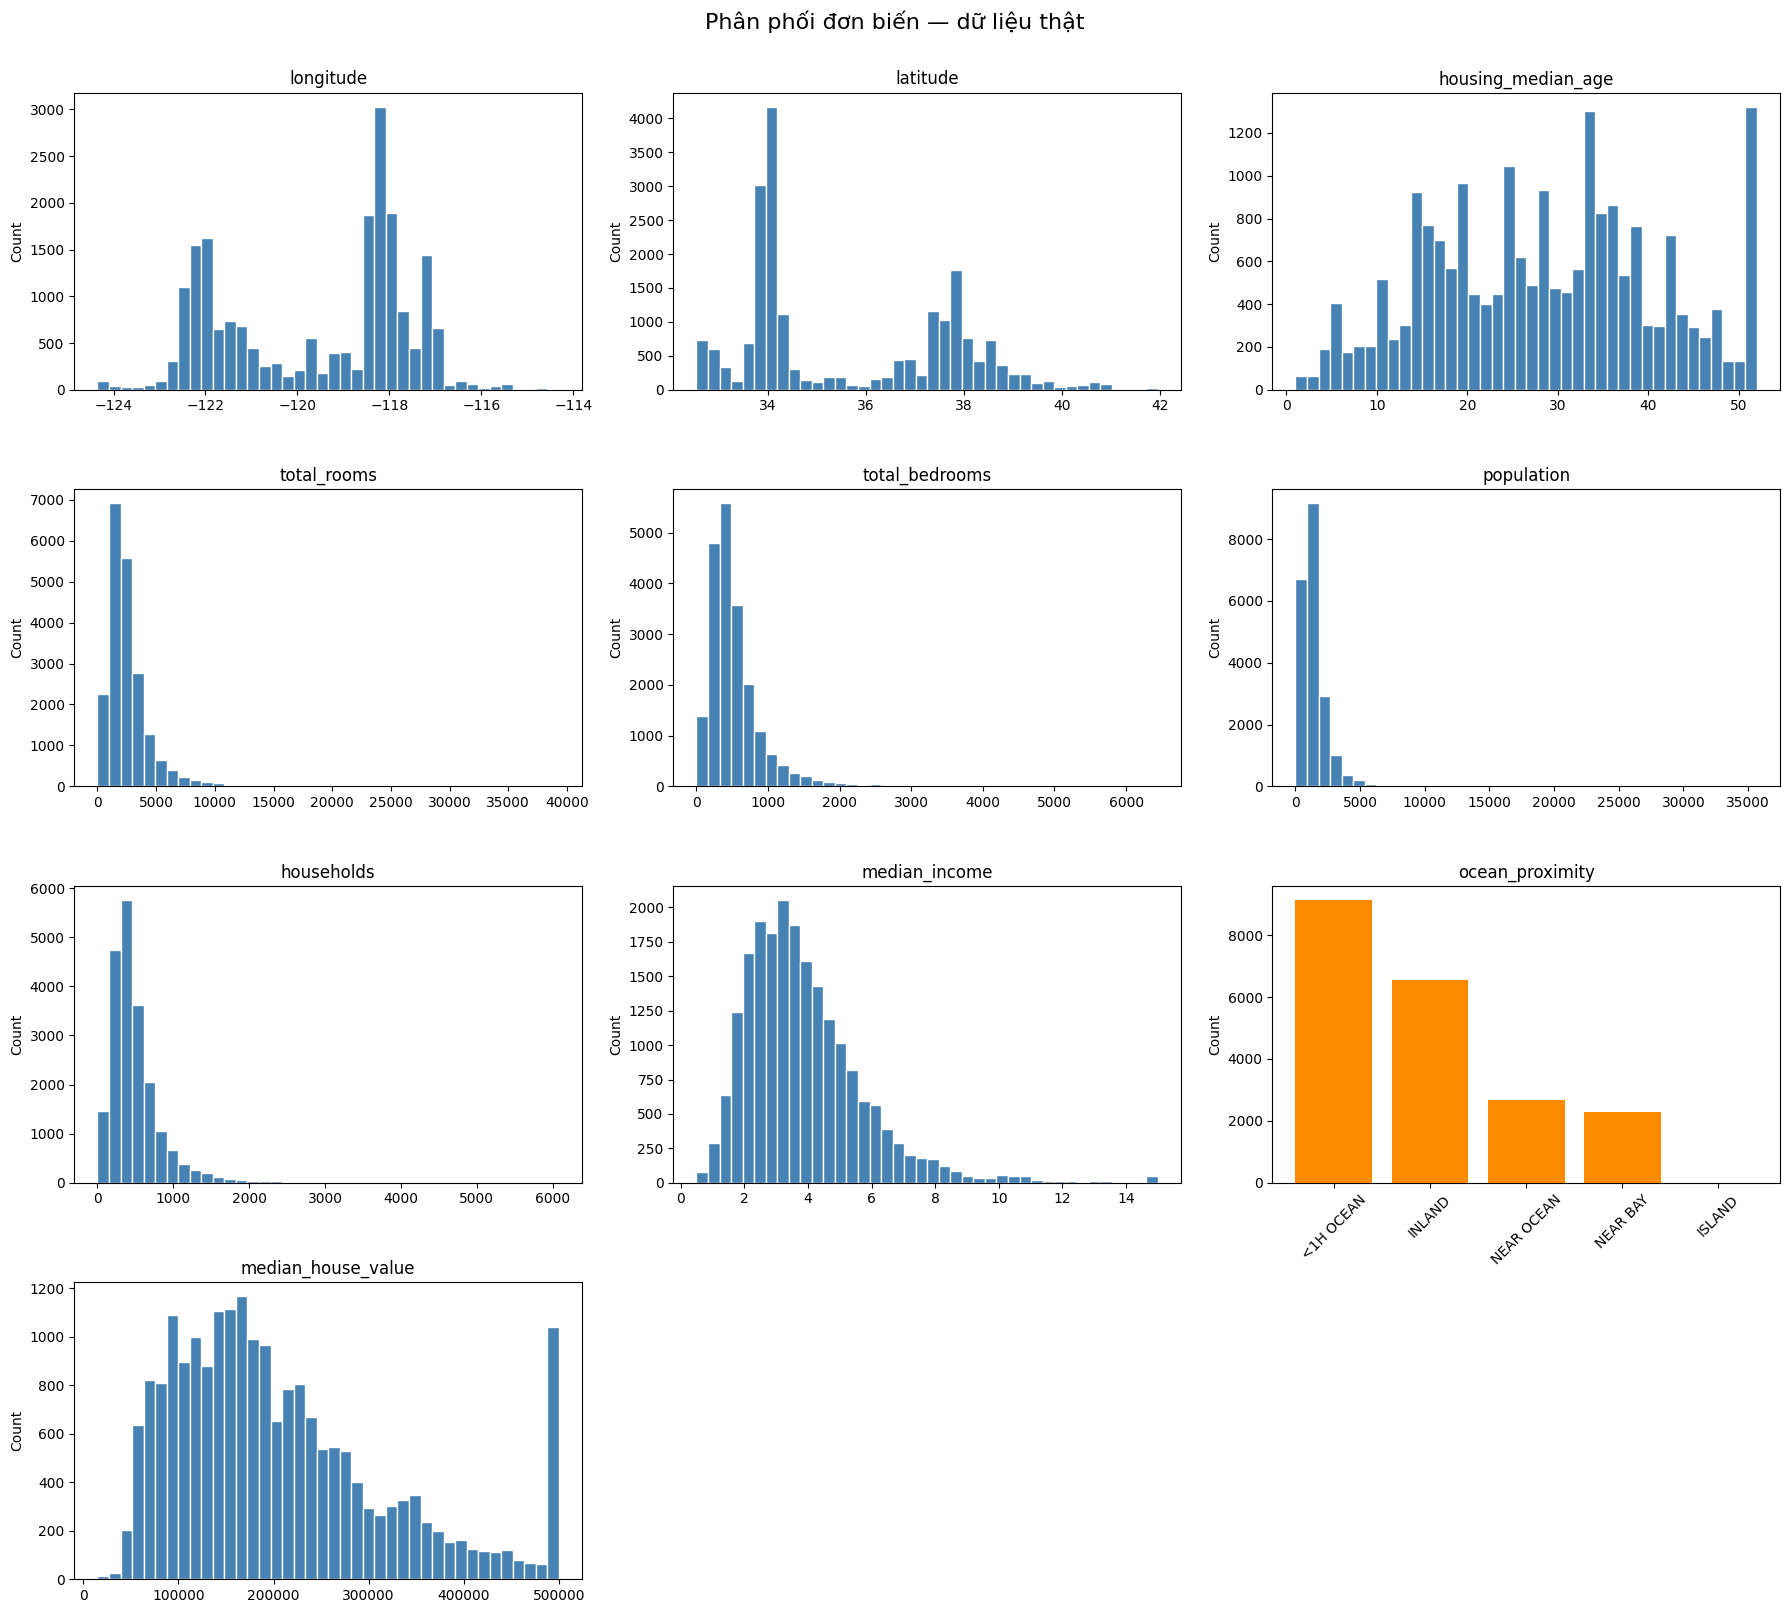

In [39]:
import matplotlib.pyplot as plt
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
cols = df.columns.tolist()
ncols = 3
nrows = int(np.ceil(len(cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*4))
axes = axes.flatten()
for i, c in enumerate(cols):
    ax = axes[i]
    if c in num_cols:
        ax.hist(df[c].dropna(), bins=40, color='steelblue', edgecolor='white')
    else:
        vc = df[c].value_counts()
        ax.bar(vc.index.astype(str), vc.values, color='darkorange')
        ax.tick_params(axis='x', rotation=45)
    ax.set_title(c); ax.set_ylabel('Count')
for j in range(len(cols), len(axes)): axes[j].set_visible(False)
plt.suptitle('Phân phối đơn biến — dữ liệu thật', fontsize=16, y=1.005)
plt.tight_layout(); plt.show()

> 📊 **Phân tích:** Các cột "tổng theo block" **lệch phải rất mạnh** (skew: `population` 4,9, `total_rooms` 4,2, `total_bedrooms` 3,5, `households` 3,4); `median_income` lệch vừa (1,65). `median_house_value` (target) lệch nhẹ (0,98) và **dồn một cột bất thường ở mốc trên** (~500k). `housing_median_age` gần đối xứng nhưng **đầy ở giá trị 52**. `ocean_proximity`: `<1H OCEAN` (9.136) và `INLAND` (6.551) chiếm đa số, **`ISLAND` chỉ 5 dòng** (cực hiếm).

## 3. Cardinality biến phân loại

**Lý do:** Xác định cardinality để chọn cách encode.

In [40]:
df[cat_cols].nunique().to_frame('n_unique').assign(n_missing=df[cat_cols].isna().sum())

,n_unique,n_missing
ocean_proximity,5,0


> 📊 **Phân tích:** Chỉ một biến phân loại `ocean_proximity` với **5 giá trị** → cardinality thấp, hợp **one-hot**. Lưu ý nhóm `ISLAND` chỉ 5 mẫu (one-hot sẽ tạo cột gần như toàn 0).

## 4. Phát hiện outlier — Boxplot

**Lý do:** Boxplot (1.5·IQR) trên dữ liệu thật để khoanh vùng outlier.

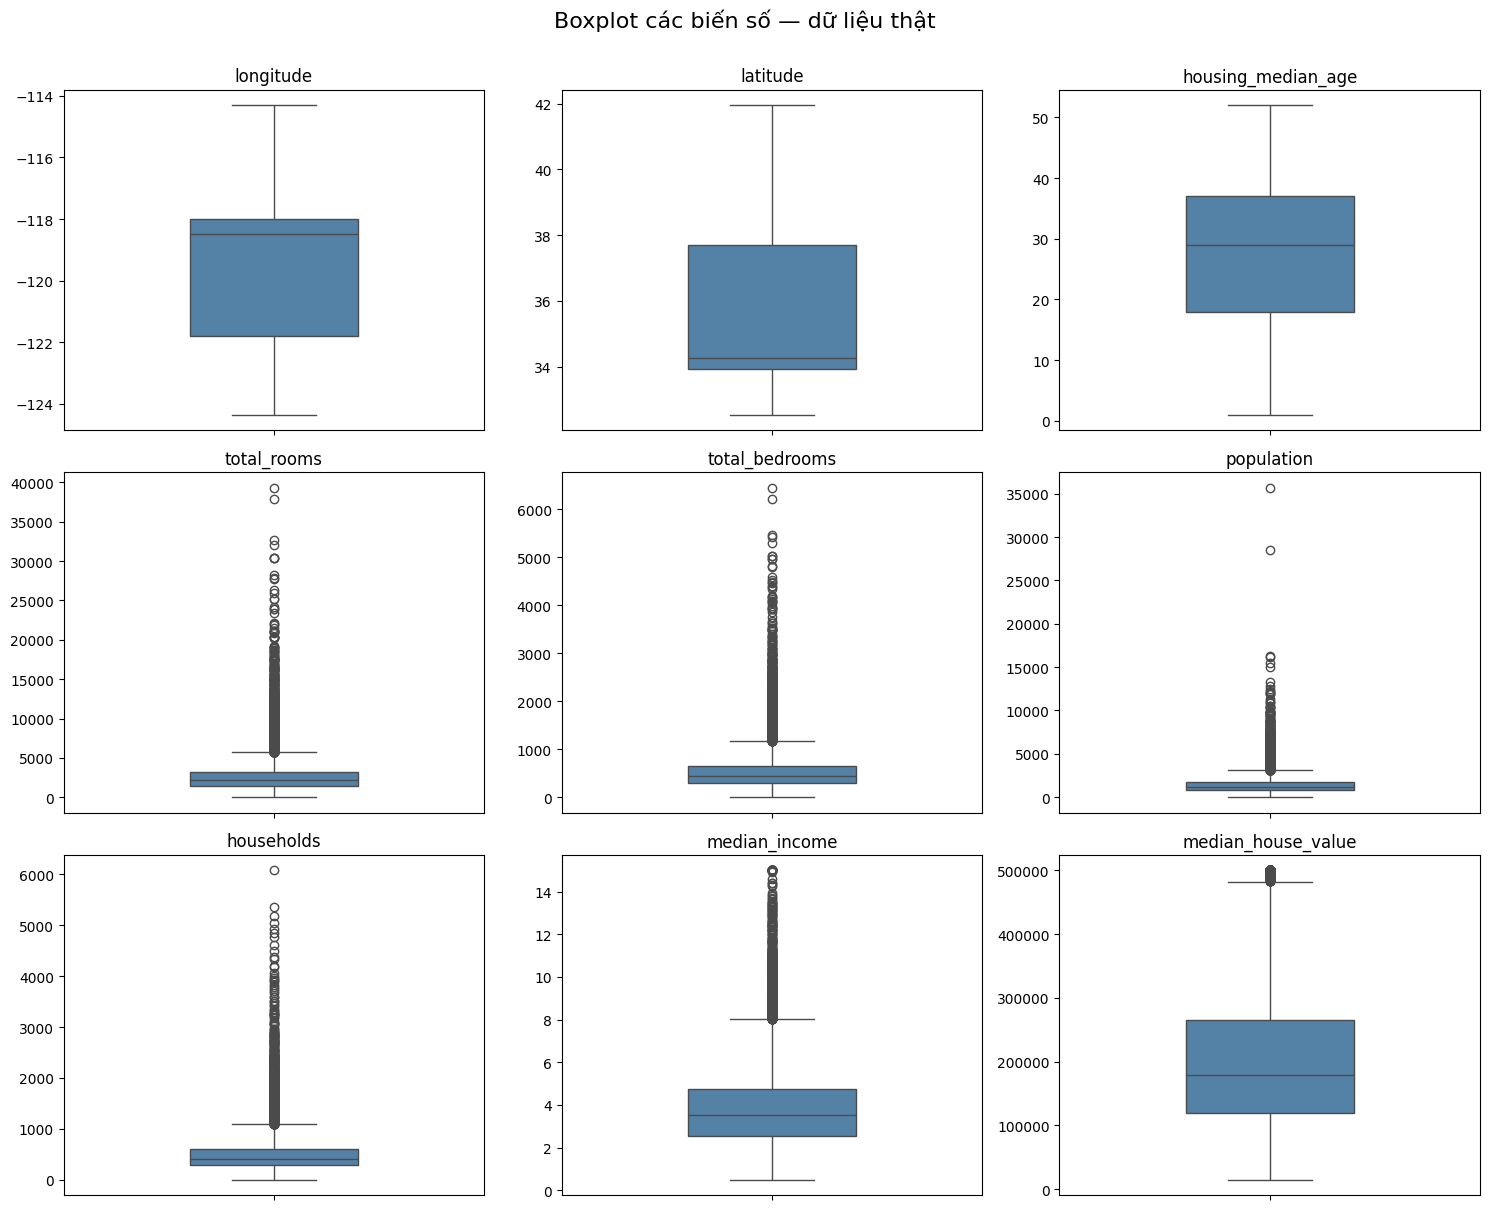

In [41]:
n = len(num_cols); ncols = 3; nrows = int(np.ceil(n/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4)); axes = axes.flatten()
for i, c in enumerate(num_cols):
    import seaborn as sns
    sns.boxplot(y=df[c].dropna(), ax=axes[i], color='steelblue', width=0.4)
    axes[i].set_title(c); axes[i].set_ylabel('')
for j in range(n, len(axes)): axes[j].set_visible(False)
plt.suptitle('Boxplot các biến số — dữ liệu thật', fontsize=16, y=1.005)
plt.tight_layout(); plt.show()

> 📊 **Phân tích:** `total_rooms`, `total_bedrooms`, `population`, `households` có **rất nhiều outlier trên** (đuôi phải dài). `median_house_value` có dải điểm dày đúng tại **trần 500.001** — dấu hiệu **dữ liệu bị cắt trần (capped)**, không phải outlier ngẫu nhiên. `housing_median_age` cũng bị **cap ở 52**. `median_income` có outlier cao (khu thu nhập lớn).

## 5. Quan hệ với target — Scatter

**Lý do:** Scatter các feature nghi ngờ với `median_house_value` để thấy quan hệ & xác nhận hiện tượng cap.

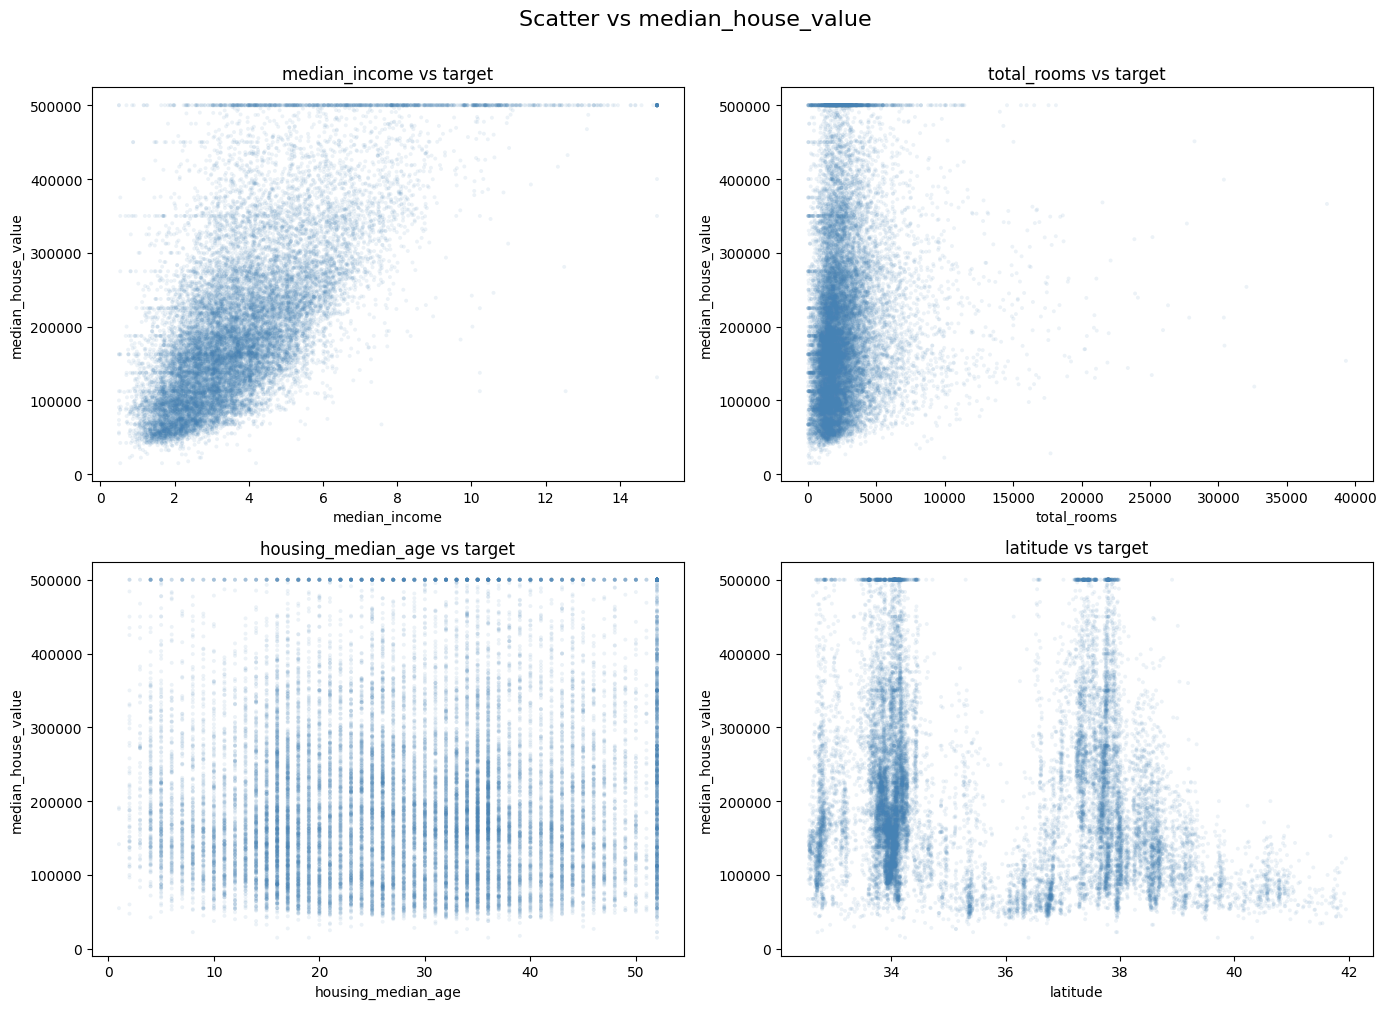

In [42]:
feats = ['median_income', 'total_rooms', 'housing_median_age', 'latitude']
fig, axes = plt.subplots(2, 2, figsize=(14, 10)); axes = axes.flatten()
for ax, c in zip(axes, feats):
    ax.scatter(df[c], df['median_house_value'], alpha=0.1, s=8, color='steelblue', edgecolors='none')
    ax.set_xlabel(c); ax.set_ylabel('median_house_value'); ax.set_title(c + ' vs target')
plt.suptitle('Scatter vs median_house_value', fontsize=16, y=1.005)
plt.tight_layout(); plt.show()

> 📊 **Phân tích:** `median_income` có **quan hệ tuyến tính dương rõ** với giá nhà (đây là predictor mạnh nhất). Cả 4 đồ thị đều lộ **đường kẻ ngang dày ở 500.001** = trần giá (965 dòng) → cần lưu ý/loại nếu mô hình nhạy. `total_rooms` dạng chữ L (vài block khổng lồ). `housing_median_age` rời rạc và đầy ở 52.

## 6. Xử lý — Log transform các biến lệch phải

**Lý do:** Các cột tổng theo block (`total_rooms`, `total_bedrooms`, `population`, `households`) và
`median_income` lệch phải mạnh → `log1p` để giảm lệch. Ghi nhận các cột bị **cap** (không phải lỗi nhập liệu)
để cân nhắc xử lý ở bước model.

median_house_value tại trần 500001: 965
housing_median_age tại trần 52     : 1273


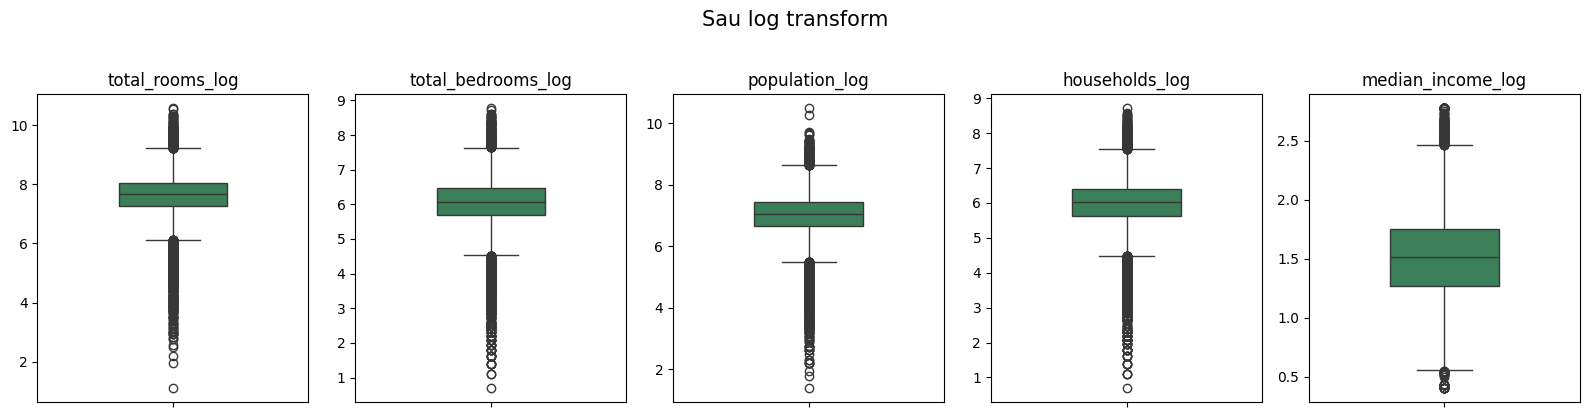

In [43]:
skew_cols = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
df_trans = df.copy()
for c in skew_cols:
    df_trans[c + '_log'] = np.log1p(df_trans[c])

# Ghi nhận giá trị bị cap
print('median_house_value tại trần 500001:', int((df['median_house_value'] == 500001).sum()))
print('housing_median_age tại trần 52     :', int((df['housing_median_age'] == 52).sum()))

import seaborn as sns
fig, axes = plt.subplots(1, len(skew_cols), figsize=(len(skew_cols)*3.2, 4))
for ax, c in zip(axes, skew_cols):
    sns.boxplot(y=df_trans[c + '_log'].dropna(), ax=ax, color='seagreen', width=0.4)
    ax.set_title(c + '_log'); ax.set_ylabel('')
plt.suptitle('Sau log transform', fontsize=15, y=1.03); plt.tight_layout(); plt.show()

> 📊 **Phân tích:** Sau `log1p`, 5 cột lệch phải chuyển sang **gần đối xứng** (hộp giãn rõ, ít outlier hơn hẳn). Phát hiện **cap**: 965 dòng `median_house_value` = 500.001 và 1.273 dòng `housing_median_age` = 52 — đây là **giới hạn thu thập dữ liệu** (đặc trưng nổi tiếng của bộ California housing), nên giữ và lưu ý, không coi là outlier để xoá.

## 7. Điền missing (cách 1) — Random sampling

**Lý do:** `total_bedrooms` thiếu ~1%. Thử random sampling (giữ phân phối biên) để so sánh.

In [44]:
rng = np.random.default_rng(42)
def random_fill(s):
    s = s.copy(); m = s.isna()
    if m.sum(): s.loc[m] = rng.choice(s.dropna().values, size=int(m.sum()), replace=True)
    return s
df_rand = df.copy()
df_rand['total_bedrooms'] = random_fill(df['total_bedrooms'])
print('missing total_bedrooms sau random fill:', int(df_rand['total_bedrooms'].isna().sum()))

missing total_bedrooms sau random fill: 0


> 📊 **Phân tích:** Random fill xoá hết 207 missing của `total_bedrooms`, giữ nguyên phân phối biên. Vì lượng thiếu **rất nhỏ (~1%)**, tác động tới phân phối là không đáng kể.

## 8. Điền missing (cách 2) — KNN imputation

**Lý do:** KNN (`weights='distance'`, scale trước) điền dựa trên block tương tự → giữ tương quan đa biến.

In [45]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Xs = scaler.fit_transform(df[num_cols])
Xi = KNNImputer(n_neighbors=5, weights='distance').fit_transform(Xs)
df_knn = df.copy()
df_knn[num_cols] = pd.DataFrame(scaler.inverse_transform(Xi), columns=num_cols, index=df.index)
print('missing các cột số sau KNN:', int(df_knn[num_cols].isna().sum().sum()))

missing các cột số sau KNN: 0


> 📊 **Phân tích:** KNN điền hết missing. Vì `total_bedrooms` rất tương quan với `households` (≈0,98), giá trị điền rất hợp lý.

## 9. Tương quan giữa các biến số — 3 góc nhìn

### 9a. Heatmap — dữ liệu thật
**Lý do:** Mốc tham chiếu; đặt `median_house_value` cuối trục để dễ đọc tương quan với target.

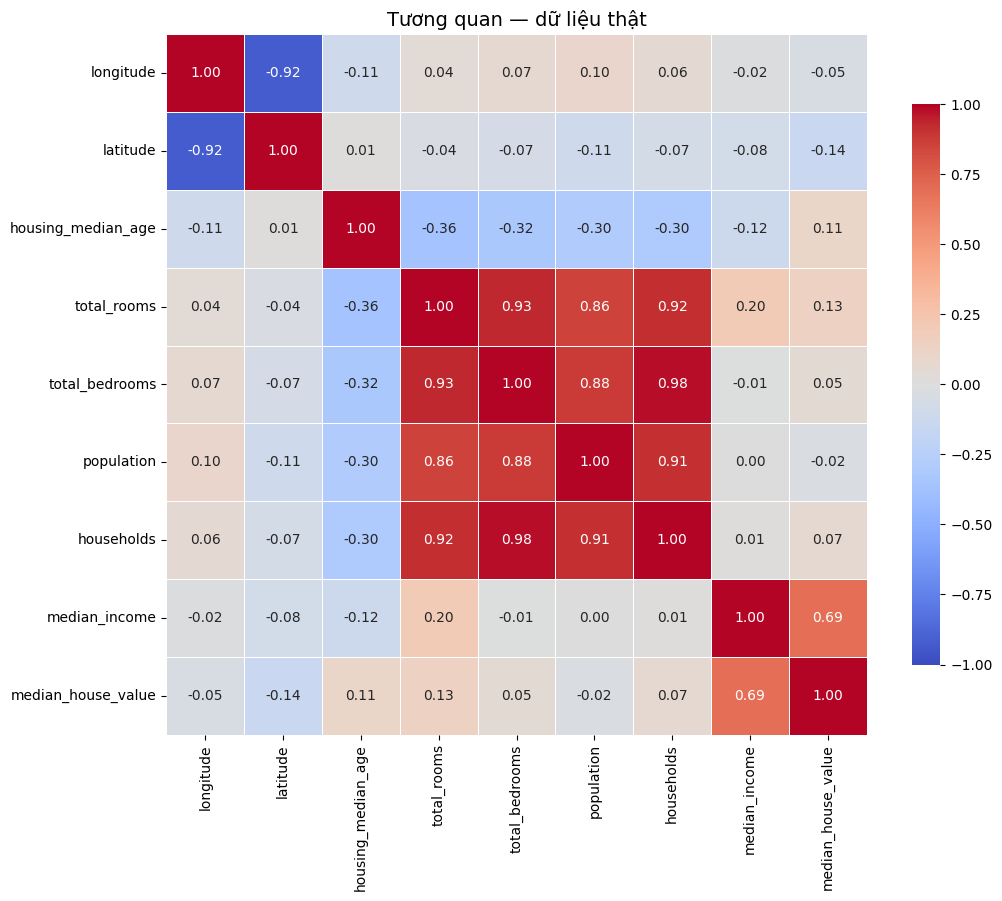

In [46]:
import seaborn as sns
order = [c for c in num_cols if c != 'median_house_value'] + ['median_house_value']
def heat(corr, title, color='coolwarm'):
    plt.figure(figsize=(11, 9))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap=color, center=0, vmin=-1, vmax=1,
                square=True, linewidths=.5, cbar_kws={'shrink': .8})
    plt.title(title, fontsize=14); plt.tight_layout(); plt.show()
heat(df[order].corr(), 'Tương quan — dữ liệu thật')

> 📊 **Phân tích (mốc):** `median_income` tương quan mạnh nhất với target (**≈0,69**), bỏ xa phần còn lại. Nhóm `total_rooms`/`total_bedrooms`/`population`/`households` **tương quan chéo rất cao** (0,85–0,98) → **đa cộng tuyến** nặng (đều phản ánh quy mô block).

### 9b. Heatmap — sau random fill
**Lý do:** So với mốc thật xem random fill ảnh hưởng tương quan thế nào.

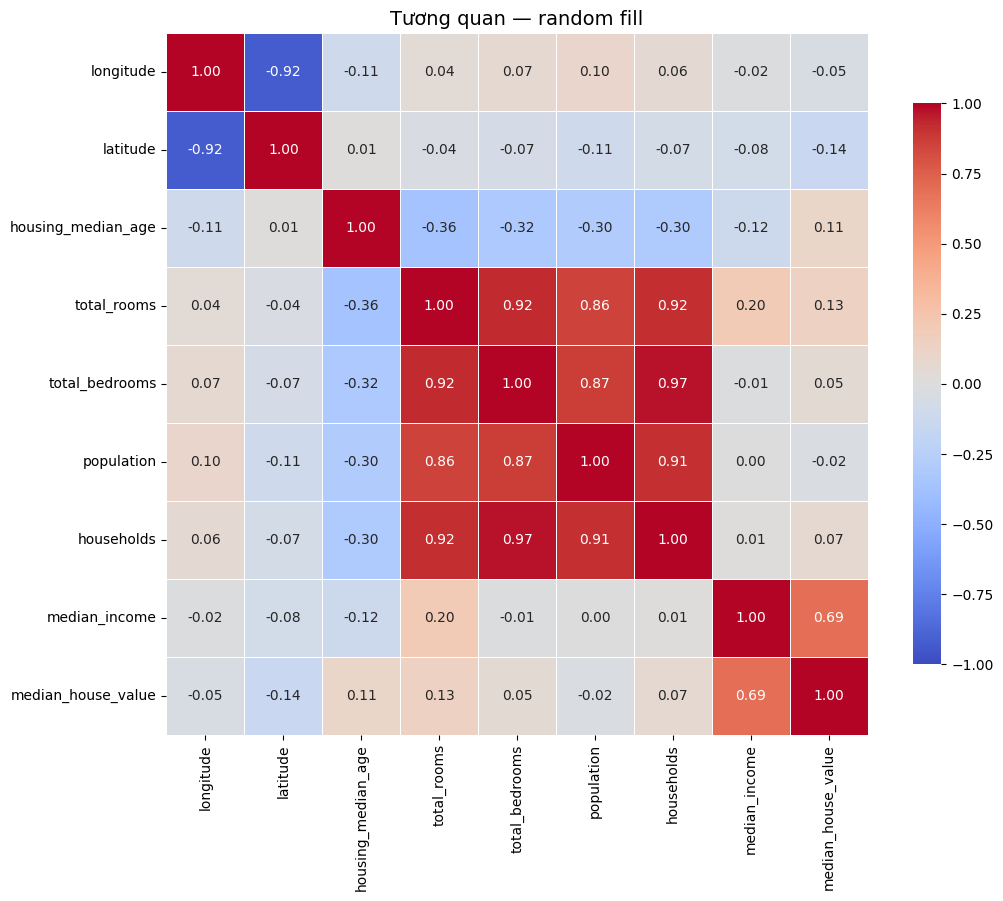

In [47]:
heat(df_rand[order].corr(), 'Tương quan — random fill')

> 📊 **Phân tích:** Gần như **trùng** bản thật — vì chỉ ~1% bị điền. `total_bedrooms–households` 0,980 → 0,970 (giảm không đáng kể).

### 9c. Heatmap — sau KNN
**Lý do:** So sánh nốt với KNN.

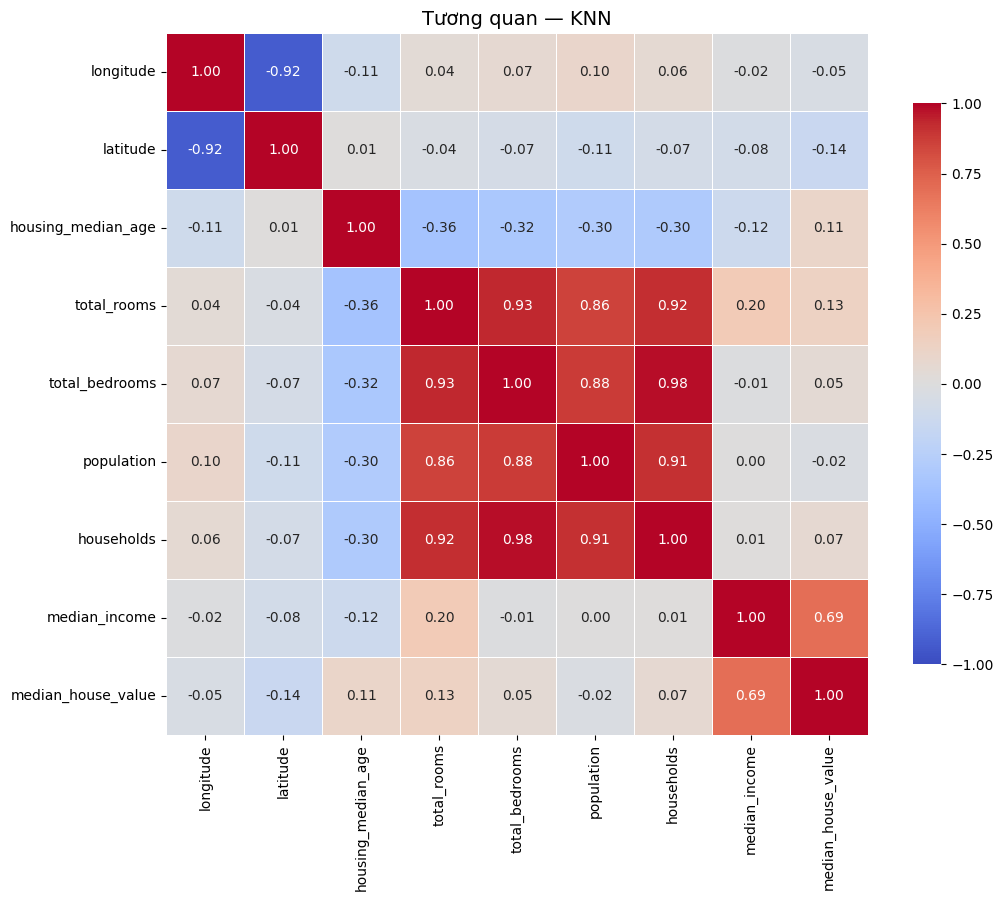

In [48]:
heat(df_knn[order].corr(), 'Tương quan — KNN')

> 📊 **Phân tích (kết luận):** KNN giữ `total_bedrooms–households` = **0,980** (đúng bản thật), random 0,970. Khác biệt **rất nhỏ** vì missing chỉ ~1% — **trái ngược với Melbourne** (thiếu 40–47%, nơi KNN vượt trội rõ). → Ở đây chọn cách nào cũng được; KNN vẫn được ưu tiên cho nhất quán.

## 10. Xếp hạng ảnh hưởng lên target

**Lý do:** |Pearson| cho biến số, **correlation ratio η** cho `ocean_proximity` (category↔số).

              feature  strength                 type
0       median_income  0.688075  numeric (|Pearson|)
1     ocean_proximity  0.487954         category (η)
2            latitude  0.144160  numeric (|Pearson|)
3         total_rooms  0.134153  numeric (|Pearson|)
4  housing_median_age  0.105623  numeric (|Pearson|)
5          households  0.065843  numeric (|Pearson|)
6      total_bedrooms  0.049686  numeric (|Pearson|)
7           longitude  0.045967  numeric (|Pearson|)
8          population  0.024650  numeric (|Pearson|)


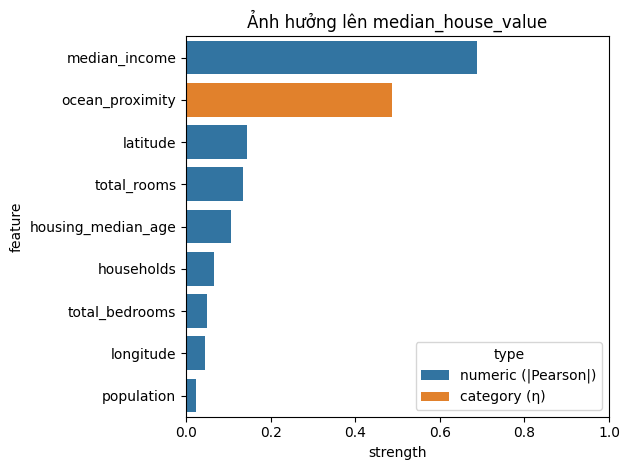

In [49]:
def correlation_ratio(categories, values):
    t = pd.DataFrame({'c': categories, 'v': values}).dropna()
    v = t['v'].values; c = t['c'].values
    sst = ((v - v.mean())**2).sum()
    if sst == 0: return 0.0
    return np.sqrt(sum(len(v[c==k])*(v[c==k].mean()-v.mean())**2 for k in pd.unique(c))/sst)

rec = []
for c in num_cols:
    if c == 'median_house_value': continue
    rec.append({'feature': c, 'strength': abs(df[[c,'median_house_value']].corr().iloc[0,1]),
                'type': 'numeric (|Pearson|)'})
for c in cat_cols:
    rec.append({'feature': c, 'strength': correlation_ratio(df[c], df['median_house_value']),
                'type': 'category (η)'})
assoc = pd.DataFrame(rec).sort_values('strength', ascending=False).reset_index(drop=True)
print(assoc)
sns.barplot(data=assoc, y='feature', x='strength', hue='type', dodge=False)
plt.title('Ảnh hưởng lên median_house_value'); plt.xlim(0,1); plt.tight_layout(); plt.show()

> 📊 **Phân tích:** Xếp hạng: **`median_income` 0,688** (áp đảo) > **`ocean_proximity` η=0,488** (vị trí biển rất quan trọng) > `latitude` 0,144 > `total_rooms` 0,134 > `housing_median_age` 0,106 ... `population`/`total_bedrooms` gần như không tương quan tuyến tính trực tiếp với giá. → hai yếu tố quyết định: **thu nhập khu vực** và **vị trí so với biển**.

## 11. Lưu dữ liệu đã xử lý ra CSV

**Lý do:** Xuất bộ sẵn sàng cho model: dùng bản log cho các cột lệch (bỏ cột raw), KNN-impute phần thiếu,
giữ `ocean_proximity`. Lưu `housing_processed.csv`.

In [50]:
df_processed = df_trans.drop(columns=skew_cols).copy()
num2 = df_processed.select_dtypes(include=np.number).columns.tolist()
scaler2 = StandardScaler()
Xs2 = scaler2.fit_transform(df_processed[num2])
Xi2 = KNNImputer(n_neighbors=5, weights='distance').fit_transform(Xs2)
df_processed[num2] = pd.DataFrame(scaler2.inverse_transform(Xi2), columns=num2, index=df_processed.index)
df_processed.to_csv('housing_processed.csv', index=False)
print('Đã lưu housing_processed.csv |', df_processed.shape, '| missing:', int(df_processed.isna().sum().sum()))
df_processed.head()

Đã lưu housing_processed.csv | (20640, 10) | missing: 0


,longitude,latitude,housing_median_age,ocean_proximity,median_house_value,total_rooms_log,total_bedrooms_log,population_log,households_log,median_income_log
0,-122.23,37.88,41.0,NEAR BAY,452600.0,6.781058,4.867534,5.777652,4.844187,2.232720
1,-122.22,37.86,21.0,NEAR BAY,358500.0,8.867850,7.009409,7.784057,7.037906,2.230165
2,-122.24,37.85,52.0,NEAR BAY,352100.0,7.291656,5.252273,6.208590,5.181784,2.111110
3,-122.25,37.85,52.0,NEAR BAY,341300.0,7.150701,5.463832,6.326149,5.393628,1.893579
4,-122.25,37.85,52.0,NEAR BAY,342200.0,7.395108,5.638355,6.338594,5.560682,1.578195


> 💾 **Kết quả:** `housing_processed.csv` — không còn missing; 5 cột lệch thay bằng bản `_log`; `ocean_proximity` giữ nguyên (encode để dành cho Pipeline).
>
> ⚠️ **Lưu ý:** (1) chưa xử lý **cap** ở `median_house_value`=500.001 (965 dòng) — cân nhắc loại khi train nếu model nhạy; (2) impute fit trên toàn bộ data → nên đưa vào `Pipeline` fit-trên-train để chống leakage.